### Recommendation Systems
**How does Netflix know what movie to recommend to you?**

A recommendaation system predicts what users might like based on past behavior.

Two main approaches:

1. **Content-Based Filtering**
   - Recommend items similar to what a user liked before.

2. **Collaborative Filtering**
   - Recommend items liked by similar users.

Today we focus on **Collaborative Filtering**.


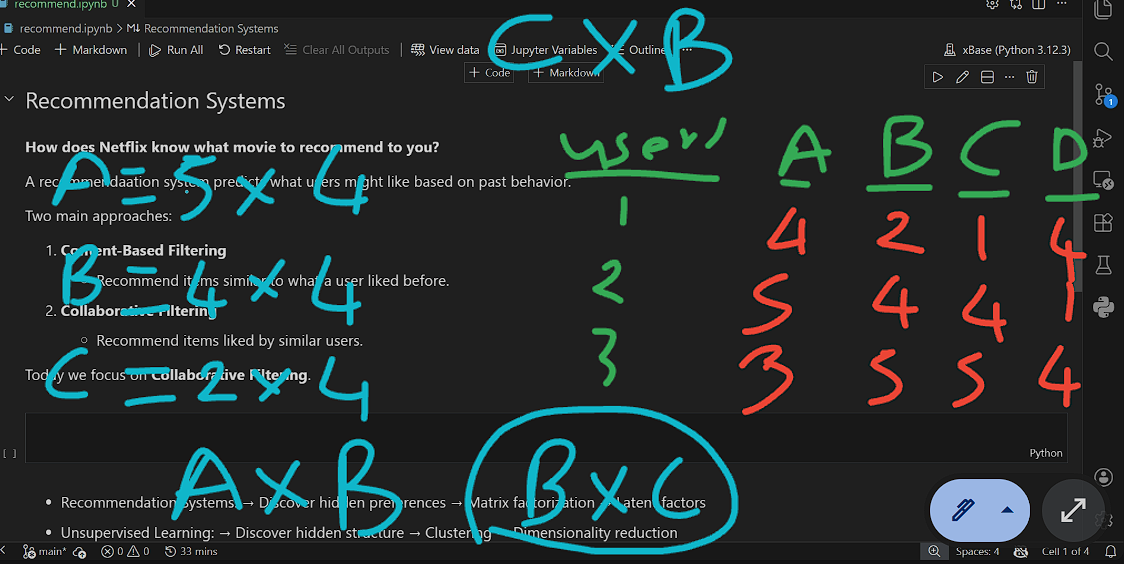


- Recommendation Systems:
    → Discover hidden preferences
    → Matrix factorization
    → Latent factors

- Unsupervised Learning:
    → Discover hidden structure
    → Clustering
    → Dimensionality reduction


In [12]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
users = ["Monicah", "David", "Lucy", "Christine", "Raphael", "Brian", "Timothy"]
movies = ["friends", "HIMYM", "seinfield", "Fast X", "Tokyo Drift", "Naruto"]


ratings = np.array([
    [5, 4, 1, 1, 2, 1],
    [4, 5, 1, 0, 1, 2],
    [1, 1, 5, 4, 2, 1],
    [1, 1, 4, 5, 1, 2],
    [2, 2, 1, 1, 5, 4],
    [1, 2, 1, 2, 4, 5],
    [4, 5, 1, 1, 1, 2]
])

df = pd.DataFrame(ratings, columns=movies, index=users)

df.head(7)

,friends,HIMYM,seinfield,Fast X,Tokyo Drift,Naruto
Monicah,5,4,1,1,2,1
David,4,5,1,0,1,2
Lucy,1,1,5,4,2,1
Christine,1,1,4,5,1,2
Raphael,2,2,1,1,5,4
Brian,1,2,1,2,4,5
Timothy,4,5,1,1,1,2


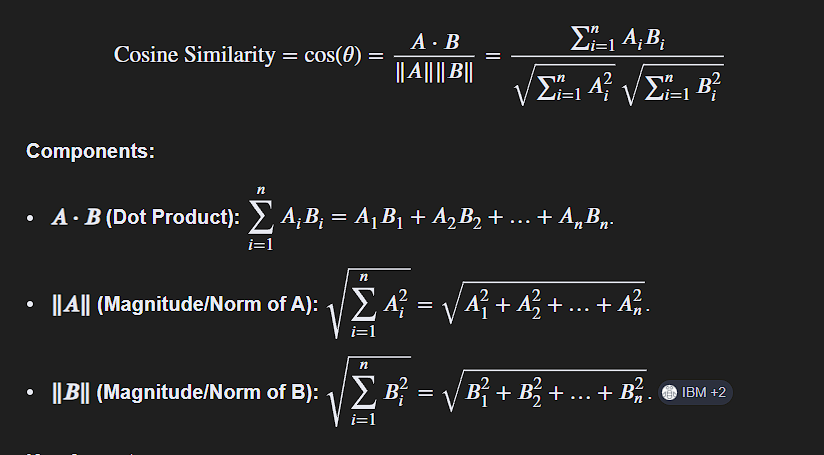

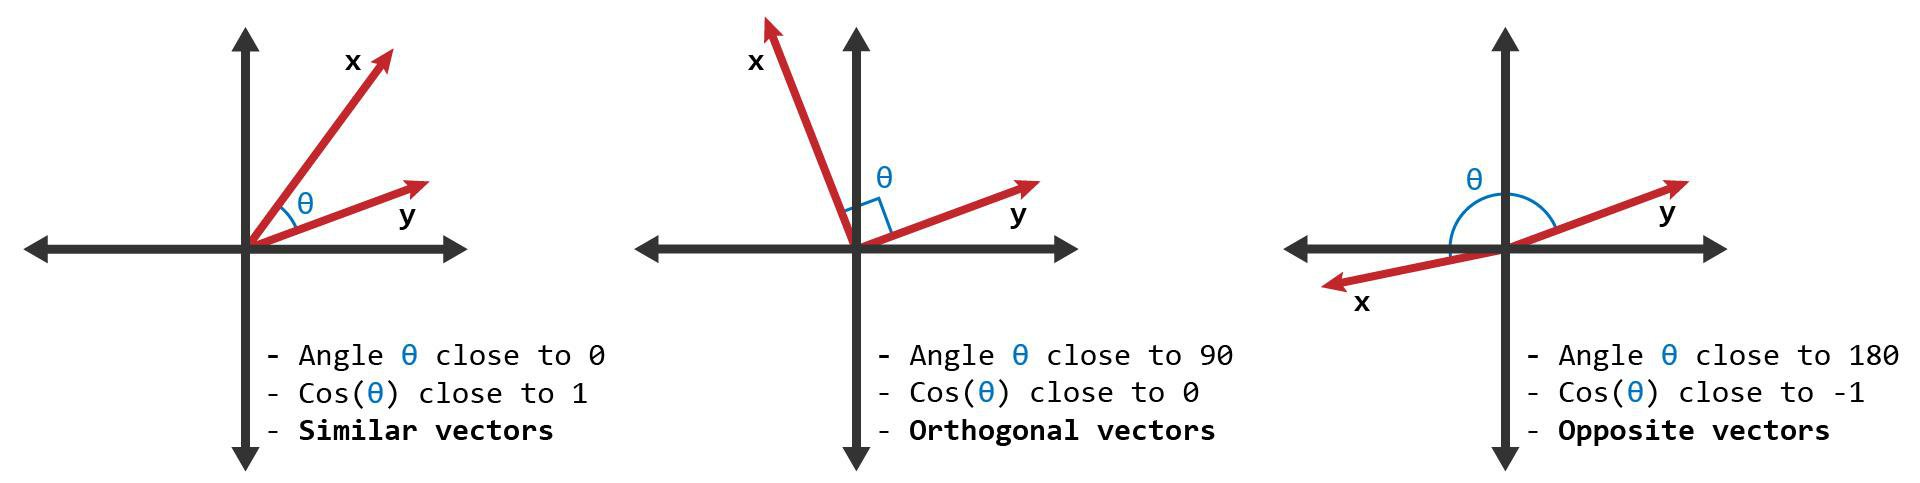

In [14]:
### cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

#apply the cosine similarity
user_similarity = cosine_similarity(df)

print(user_similarity)


[[1.         0.94742091 0.47916667 0.45833333 0.68718427 0.58612776
  0.95833333]
 [0.94742091 1.         0.37896836 0.37896836 0.6536059  0.59233034
  0.98952851]
 [0.47916667 0.37896836 1.         0.95833333 0.54570516 0.58612776
  0.45833333]
 [0.45833333 0.37896836 0.95833333 1.         0.52549385 0.62655036
  0.47916667]
 [0.68718427 0.6536059  0.54570516 0.52549385 1.         0.96078431
  0.66697297]
 [0.58612776 0.59233034 0.58612776 0.62655036 0.96078431 1.
  0.62655036]
 [0.95833333 0.98952851 0.45833333 0.47916667 0.66697297 0.62655036
  1.        ]]


In [15]:
user_df = pd.DataFrame(user_similarity, columns=users, index=users)

user_df.head(7)

,Monicah,David,Lucy,Christine,Raphael,Brian,Timothy
Monicah,1.000000,0.947421,0.479167,0.458333,0.687184,0.586128,0.958333
David,0.947421,1.000000,0.378968,0.378968,0.653606,0.592330,0.989529
Lucy,0.479167,0.378968,1.000000,0.958333,0.545705,0.586128,0.458333
Christine,0.458333,0.378968,0.958333,1.000000,0.525494,0.626550,0.479167
Raphael,0.687184,0.653606,0.545705,0.525494,1.000000,0.960784,0.666973
Brian,0.586128,0.592330,0.586128,0.626550,0.960784,1.000000,0.626550
Timothy,0.958333,0.989529,0.458333,0.479167,0.666973,0.626550,1.000000


In [16]:
#looking for users similar to david
david_sim = user_df['David']

#weighted average ratings 
scores = df.T.dot(david_sim) / david_sim.sum()

scores.sort_values(ascending=False)

HIMYM          3.438119
friends        3.107316
Naruto         2.355773
Tokyo Drift    2.157258
seinfield      1.536910
Fast X         1.454400
dtype: float64

In [17]:
df.head(6)

,friends,HIMYM,seinfield,Fast X,Tokyo Drift,Naruto
Monicah,5,4,1,1,2,1
David,4,5,1,0,1,2
Lucy,1,1,5,4,2,1
Christine,1,1,4,5,1,2
Raphael,2,2,1,1,5,4
Brian,1,2,1,2,4,5


In [18]:
#drop user from similarity 
david_sim = user_df['David'].drop('David')

david_sim.head(7)

Monicah      0.947421
Lucy         0.378968
Christine    0.378968
Raphael      0.653606
Brian        0.592330
Timothy      0.989529
Name: David, dtype: float64

In [19]:
df.columns

Index(['friends', 'HIMYM', 'seinfield', 'Fast X', 'Tokyo Drift', 'Naruto'], dtype='object')

In [20]:
david_sim

Monicah      0.947421
Lucy         0.378968
Christine    0.378968
Raphael      0.653606
Brian        0.592330
Timothy      0.989529
Name: David, dtype: float64

In [21]:
df.loc[david_sim.index, movies]

,friends,HIMYM,seinfield,Fast X,Tokyo Drift,Naruto
Monicah,5,4,1,1,2,1
Lucy,1,1,5,4,2,1
Christine,1,1,4,5,1,2
Raphael,2,2,1,1,5,4
Brian,1,2,1,2,4,5
Timothy,4,5,1,1,1,2


In [22]:
david_sim.values

array([0.94742091, 0.37896836, 0.37896836, 0.6536059 , 0.59233034,
       0.98952851])

In [23]:
#predictions dictionary-----> title and rating

preds = {}


for movie in df.columns:
    weighted_sum = np.dot(david_sim, df.loc[david_sim.index, movies])
    normalization = david_sim.abs().sum()
    preds[movie] = weighted_sum / normalization

ratings_pred = pd.DataFrame(preds)

ratings_pred
    



,friends,HIMYM,seinfield,Fast X,Tokyo Drift,Naruto
0,2.880794,2.880794,2.880794,2.880794,2.880794,2.880794
1,3.041785,3.041785,3.041785,3.041785,3.041785,3.041785
2,1.673154,1.673154,1.673154,1.673154,1.673154,1.673154
3,1.823460,1.823460,1.823460,1.823460,1.823460,1.823460
4,2.450916,2.450916,2.450916,2.450916,2.450916,2.450916
5,2.446052,2.446052,2.446052,2.446052,2.446052,2.446052


In [24]:
i = df.loc['David'] >= 3
i

friends         True
HIMYM           True
seinfield      False
Fast X         False
Tokyo Drift    False
Naruto         False
Name: David, dtype: bool

In [25]:
df.loc['David'] >= 3

ratings_pred

,friends,HIMYM,seinfield,Fast X,Tokyo Drift,Naruto
0,2.880794,2.880794,2.880794,2.880794,2.880794,2.880794
1,3.041785,3.041785,3.041785,3.041785,3.041785,3.041785
2,1.673154,1.673154,1.673154,1.673154,1.673154,1.673154
3,1.823460,1.823460,1.823460,1.823460,1.823460,1.823460
4,2.450916,2.450916,2.450916,2.450916,2.450916,2.450916
5,2.446052,2.446052,2.446052,2.446052,2.446052,2.446052


In [26]:
""" 
break this 6 * 6 matrix into 3 matrices 

SVD ----> Singular Value Decomposition

R = U * Sigma * (V ^ t)

"""

from sklearn.decomposition import TruncatedSVD
from numpy.linalg import svd

svd = TruncatedSVD(n_components=3)

U = svd.fit_transform(ratings)  # 6 * 3 -----> User-user latent feature
sigma = svd.singular_values_    # 1 * 3 -----> vector/ singular values
Vt = svd.components_            # 3 * 6  ----> item-item latent features

print(U)

[[ 6.12930776 -2.60174454 -1.38218819]
 [ 5.88416842 -3.24713589 -1.07855977]
 [ 5.05472909  4.23015153 -1.8633371 ]
 [ 5.08051927  4.26472945 -1.7565062 ]
 [ 6.23958068  0.21623051  3.34765053]
 [ 6.13308693  1.18115544  3.35765447]
 [ 6.20462832 -2.67365562 -1.3409039 ]]


In [27]:
U

array([[ 6.12930776, -2.60174454, -1.38218819],
       [ 5.88416842, -3.24713589, -1.07855977],
       [ 5.05472909,  4.23015153, -1.8633371 ],
       [ 5.08051927,  4.26472945, -1.7565062 ],
       [ 6.23958068,  0.21623051,  3.34765053],
       [ 6.13308693,  1.18115544,  3.35765447],
       [ 6.20462832, -2.67365562, -1.3409039 ]])

In [28]:
print(sigma)

[15.44662905  7.87307968  5.82320405]


In [29]:
print(Vt)

[[ 0.45159249  0.50227421  0.31930856  0.3204599   0.39928039  0.42391922]
 [-0.42886548 -0.46335573  0.50148154  0.57348027  0.11948827  0.08206745]
 [-0.29949194 -0.23106377 -0.3963189  -0.26234413  0.57511116  0.54796729]]


In [30]:
pd.DataFrame(np.dot(U, Vt), index=df.index, columns=df.columns)

,friends,HIMYM,seinfield,Fast X,Tokyo Drift,Naruto
Monicah,4.297702,4.603500,1.200201,0.834757,1.341523,1.627419
David,4.372851,4.709261,0.677940,0.306425,1.341147,1.636912
Lucy,1.026566,1.009345,4.473837,4.534582,1.452082,1.468907
Christine,0.991389,0.981592,4.457073,4.534650,1.527951,1.541217
Raphael,1.722420,2.260268,0.774050,1.245303,4.442450,4.497227
Brian,1.257509,1.757364,1.219973,1.761917,4.520980,4.536753
Timothy,4.350192,4.665113,1.171828,0.806824,1.386747,1.676070


In [31]:
ratings

array([[5, 4, 1, 1, 2, 1],
       [4, 5, 1, 0, 1, 2],
       [1, 1, 5, 4, 2, 1],
       [1, 1, 4, 5, 1, 2],
       [2, 2, 1, 1, 5, 4],
       [1, 2, 1, 2, 4, 5],
       [4, 5, 1, 1, 1, 2]])

In [32]:
sigma
C:\Users\marwa\Desktop\dsf_pt13\Phase4\recommendation\recommend.ipynb

SyntaxError: unexpected character after line continuation character (1077942272.py, line 2)

#### 4TH MARCH 2025

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

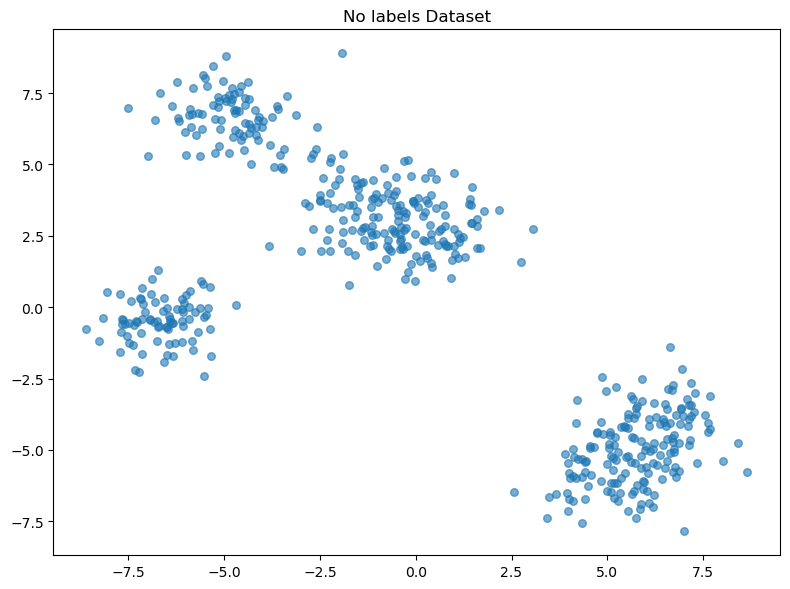

In [33]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate synthetic dataset
X, y_true = make_blobs(n_samples=500, centers=6, cluster_std=0.9, random_state=254)

# Plot the dataset
plt.figure(figsize=(8, 6))   # lowercase 'figure'
plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.6)
plt.title('No labels Dataset')
plt.tight_layout()
plt.show()



In [35]:
"""
A      B      C
128    12    1000
834    31    887  
958    75    500
711    82    433
222    99    110
881    101   254
"""

# Standard scaler sets the Mean = 0 and Standard deviation = 1


'\nA      B      C\n128    12    1000\n834    31    887  \n958    75    500\n711    82    433\n222    99    110\n881    101   254\n'

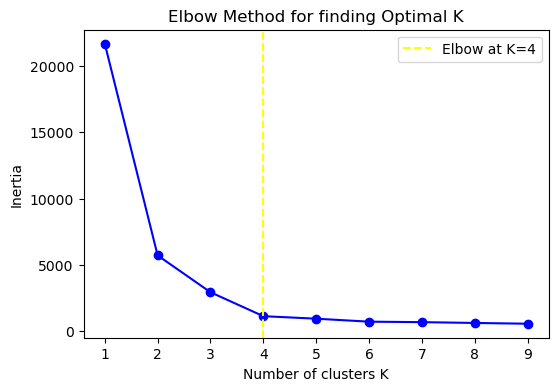

In [44]:
# elbow plot
inertia = []
k_range = range(1, 10)

for k in k_range:
  km = KMeans(n_clusters=k, random_state=24, n_init='auto')
  km.fit(X)
  inertia.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, inertia, "bo-")
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method for finding Optimal K')
plt.axvline(x=4, color='yellow', linestyle="--", label='Elbow at K=4')
plt.legend()
plt.show()

### Mall Customers

In [49]:
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()

X_scaled =  scaler.fit_transform(X)

Km_final = KMeans(n_clusters=4, random_state=24)
labels = Km_final.fit_predict(X_scaled)


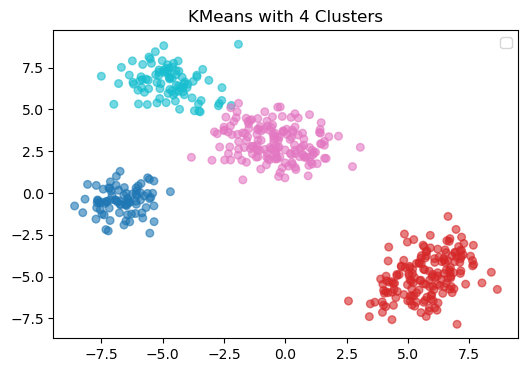

In [51]:
plt.figure(figsize=(6, 4))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30, alpha=0.6)
# plt.scatter(
#     km_final.cluster_centers_[:, 0],
#     km_final.cluster_centers_[:, 1],
#     s=200, c='black', marker='X', label="Centroids"
# )
plt.title('KMeans with 4 Clusters')
plt.legend()
plt.show()

In [52]:
X_scaled

array([[-4.41700843e-01,  4.33641566e-01],
       [-1.27602324e+00, -2.21127435e-01],
       [-2.41367916e-01,  4.31472545e-01],
       [ 1.60953871e+00, -1.07442156e+00],
       [-9.53552895e-01,  1.62837802e+00],
       [-2.92651002e-01,  9.09463484e-01],
       [-8.64610669e-01,  1.67792145e+00],
       [-1.00886256e+00,  1.37448607e+00],
       [ 1.36791146e+00, -1.17805311e+00],
       [ 1.08215920e+00, -1.09879327e+00],
       [-8.02170584e-02,  7.86234955e-01],
       [ 9.09433456e-02,  3.15204926e-01],
       [-8.60445620e-01,  1.27255577e+00],
       [-1.06754656e+00,  6.58362902e-02],
       [ 1.10548961e+00, -1.11900409e+00],
       [-1.35203013e+00,  1.95691594e-01],
       [ 1.31687822e+00, -8.49640033e-01],
       [-1.44701898e+00, -2.56688488e-02],
       [-1.43630169e+00, -1.88638063e-01],
       [-3.73244866e-02,  3.81819951e-01],
       [-1.17573095e+00,  1.46621802e+00],
       [-4.98083279e-01,  1.14776260e+00],
       [ 8.99942926e-01, -1.00854405e+00],
       [-7.

In [53]:
df = pd.read_csv('./mall_customers.csv', index_col='Unnamed: 0')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            200 non-null    int64 
 1   AnnualIncome   200 non-null    int64 
 2   SpendingScore  200 non-null    int64 
 3   Genre          200 non-null    object
dtypes: int64(3), object(1)
memory usage: 7.8+ KB


In [55]:
df['Genre'].unique()

array(['Female', 'Male'], dtype=object)

In [64]:
df['Genre'] = df['Genre'].map({'Male':0, "Female":1})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            200 non-null    int64  
 1   AnnualIncome   200 non-null    int64  
 2   SpendingScore  200 non-null    int64  
 3   Genre          0 non-null      float64
dtypes: float64(1), int64(3)
memory usage: 7.8 KB


In [65]:
X = df[['Age', 'AnnualIncome', 'SpendingScore']]

scaler = StandardScaler()
X_scaled =  scaler.fit_transform(X)


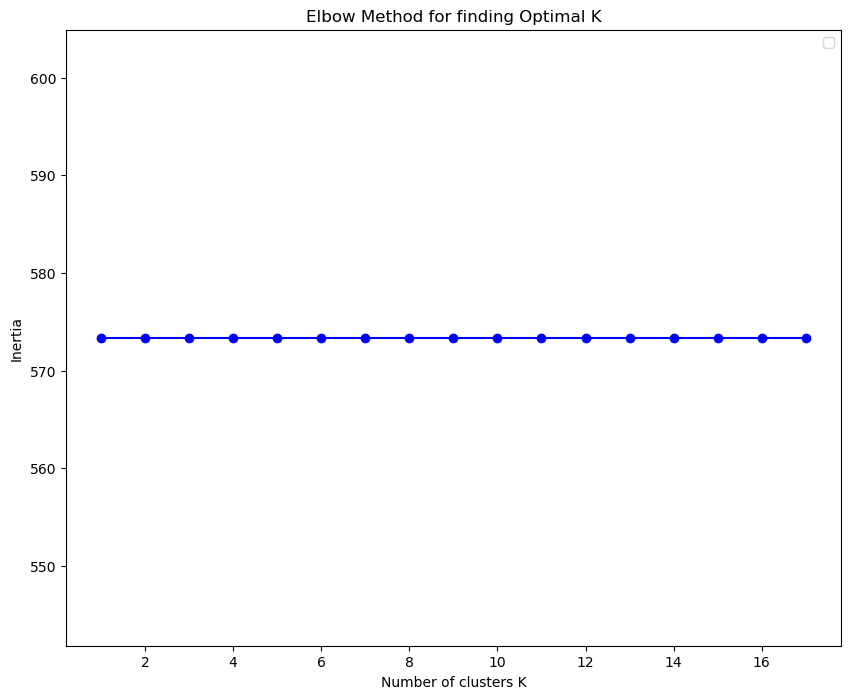

In [70]:
inertia = []

k_range = range(1, 18)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=24, n_init=10 )
    kmeans.fit(X_scaled)
    inertia.append(km.inertia_)


plt.figure(figsize=(10, 8))
plt.plot(k_range, inertia, "bo-")
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method for finding Optimal K')
# plt.axvline(x=4, color='yellow', linestyle="--", label='Elbow at K=4')
plt.legend()
plt.show()

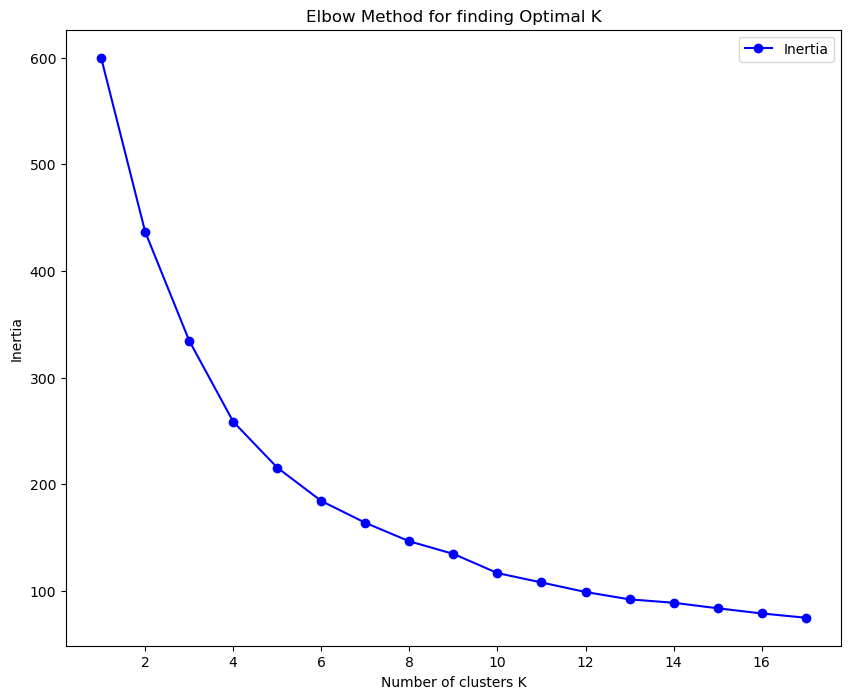

In [71]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 18)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=24, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)   # fixed variable name

plt.figure(figsize=(10, 8))
plt.plot(k_range, inertia, "bo-", label="Inertia")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia")
plt.title("Elbow Method for finding Optimal K")
# Example: highlight elbow at K=4
# plt.axvline(x=4, color="yellow", linestyle="--", label="Elbow at K=4")
plt.legend()
plt.show()

In [74]:
from sklearn.cluster import KMeans

# With 11 as the chosen optimal k
kmeans = KMeans(n_clusters=11, random_state=24, n_init=10)
df_copy['cluster'] = kmeans.fit_predict(X_scaled)


NameError: name 'df_copy' is not defined